# 03 - Modeling with FLAML AutoML

Runs FLAML AutoML on the SMOTE-balanced training partition, then evaluates on the untouched holdout.

**Objective:** F1 on the fraud class. We do NOT optimise accuracy.

In [11]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'code'))

import pandas as pd
from IPython.display import Image, display
from utils.paths import REPORTS, MODELS
from modeling import train

## Run training

Time-budgeted AutoML (default 120s) across LightGBM, XGBoost, RandomForest, ExtraTrees and L1 Logistic Regression.

In [12]:
metrics = train.train()
metrics

2026-05-26 15:52:20 | INFO     | train | Loaded splits: X_train=(15200, 19) X_test=(2000, 19)
2026-05-26 15:52:20 | INFO     | train | Data validation passed | train targets: {0: np.int64(7600), 1: np.int64(7600)} | test targets: {0: np.int64(1900), 1: np.int64(100)}
2026-05-26 15:52:20 | INFO     | train | Starting FLAML AutoML with settings={'time_budget': 120, 'metric': 'f1', 'task': 'classification', 'estimator_list': ['lgbm', 'xgboost', 'rf', 'extra_tree', 'lrl1'], 'eval_method': 'cv', 'n_splits': 5, 'seed': 42, 'log_file_name': 'C:\\Users\\U1\\Documents\\fraud-1\\outputs\\reports\\flaml_search.log', 'verbose': 1}
2026-05-26 15:54:21 | INFO     | train | Best estimator: extra_tree
2026-05-26 15:54:21 | INFO     | train | Best CV loss (1 - f1): 0.02068
2026-05-26 15:54:21 | INFO     | train | Best config: {'n_estimators': 64, 'max_features': np.float64(0.2167917063349878), 'max_leaves': 1256, 'criterion': np.str_('gini')}
2026-05-26 15:54:21 | INFO     | train | Holdout metrics | p

{'precision': 0.5217391304347826,
 'recall': 0.24,
 'f1': 0.3287671232876712,
 'pr_auc': 0.39486732699911753,
 'roc_auc': 0.9054578947368421,
 'best_estimator': 'extra_tree',
 'best_cv_loss': 0.020677337645803262,
 'best_config': {'n_estimators': 64,
  'max_features': np.float64(0.2167917063349878),
  'max_leaves': 1256,
  'criterion': np.str_('gini')},
 'time_budget_seconds': 120,
 'trained_at': '2026-05-26T15:54:21'}

## Holdout metrics

We report precision, recall, F1, PR-AUC, ROC-AUC. Accuracy is intentionally omitted from the dashboard.

In [13]:
headline = {k: metrics[k] for k in ['precision', 'recall', 'f1', 'pr_auc', 'roc_auc', 'best_estimator']}
pd.Series(headline, name='value').to_frame()

,value
precision,0.521739
recall,0.24
f1,0.328767
pr_auc,0.394867
roc_auc,0.905458
best_estimator,extra_tree


In [14]:
print((REPORTS / 'classification_report.txt').read_text())

              precision    recall  f1-score   support

       legit     0.9611    0.9884    0.9746      1900
       fraud     0.5217    0.2400    0.3288       100

    accuracy                         0.9510      2000
   macro avg     0.7414    0.6142    0.6517      2000
weighted avg     0.9391    0.9510    0.9423      2000



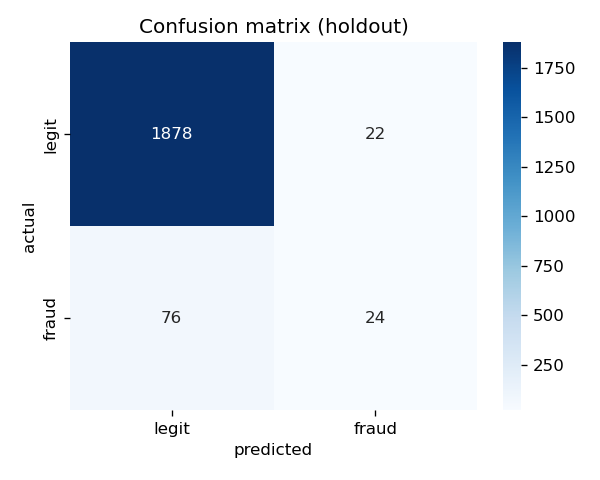

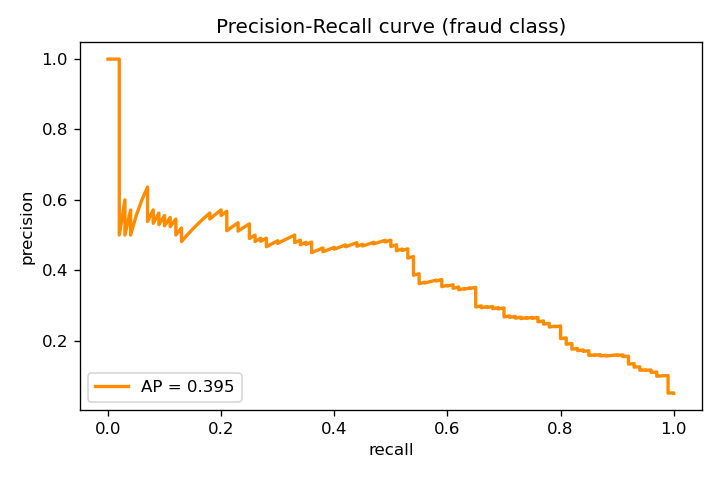

In [15]:
for name in ['confusion_matrix.png', 'precision_recall_curve.png']:
    p = REPORTS / name
    if p.exists():
        display(Image(filename=str(p)))

## Persisted artifacts
- `outputs/models/flaml_automl_model.pkl` -- the fitted AutoML object.
- `outputs/models/encoder.pkl` -- one-hot encoder for inference.
- `outputs/models/feature_schema.json` -- feature column order required at inference.
- `outputs/reports/metrics.json` -- structured metrics for downstream comparison.

Score new batches via:
```
python code/deployment/predict.py --input data/raw/new.csv --output outputs/reports/predictions.csv
```